In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import zipfile

zip_path = "/content/archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/alzheimers_data")

print("ZIP extracted successfully!")

ZIP extracted successfully!


In [ ]:
import pandas as pd

df = pd.read_csv('/content/alzheimers_data/alzheimers_disease_data.csv')

df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [ ]:
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [ ]:
df['Diagnosis'].value_counts()

,count
Diagnosis,
0,1389
1,760


In [ ]:
df = df.drop(['PatientID', 'DoctorInCharge'], axis=1)

In [ ]:
X = df.drop('Diagnosis', axis=1)

y = df['Diagnosis']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import Perceptron

model = Perceptron()

model.fit(X_train, y_train)

Perceptron()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7465116279069768


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.81      0.80       277
           1       0.64      0.64      0.64       153

    accuracy                           0.75       430
   macro avg       0.72      0.72      0.72       430
weighted avg       0.75      0.75      0.75       430



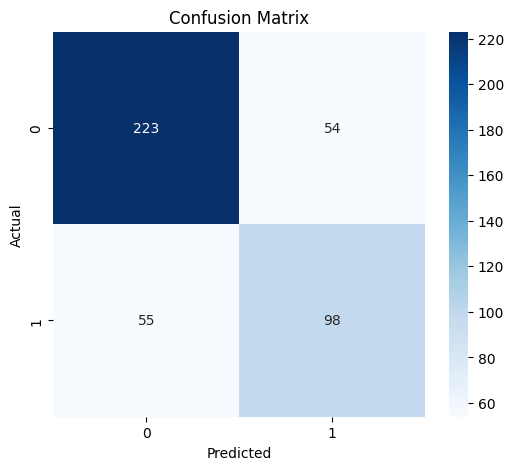

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

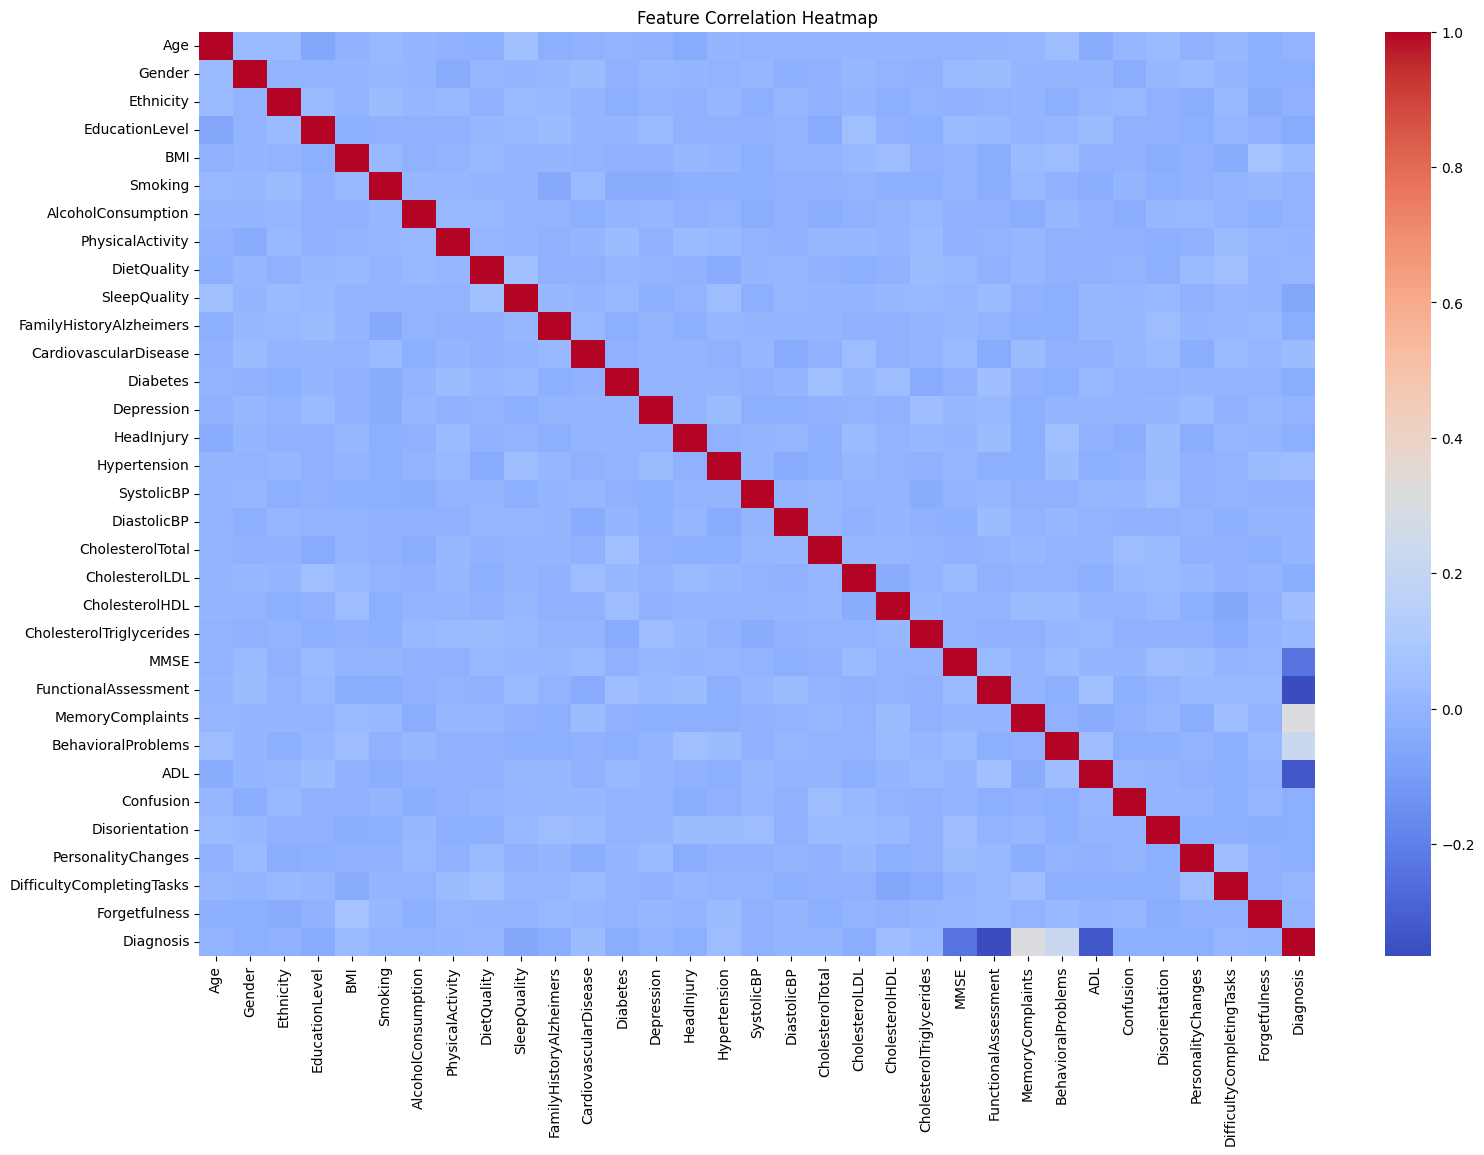

In [ ]:
plt.figure(figsize=(18,12))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Feature Correlation Heatmap")

plt.show()

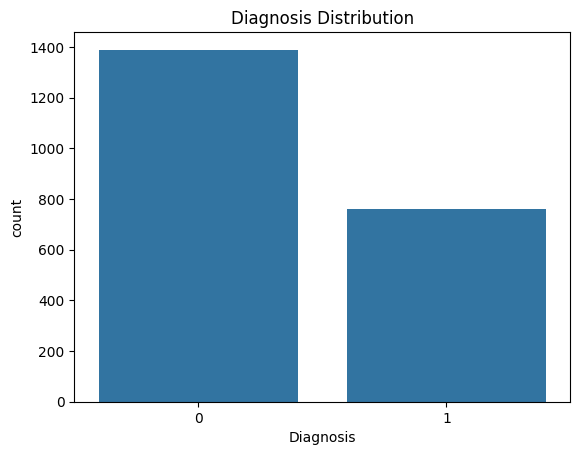

In [ ]:
sns.countplot(x='Diagnosis', data=df)

plt.title("Diagnosis Distribution")

plt.show()

In [ ]:
def decision_support(prediction):

    if prediction == 1:
        return "High Alzheimer’s risk detected. Recommend neurologist consultation."

    else:
        return "Low Alzheimer’s risk detected. Continue regular monitoring."

In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)[0]

print("Prediction:", prediction)

print(decision_support(prediction))

Prediction: 0
Low Alzheimer’s risk detected. Continue regular monitoring.


**Bias Reduction Techniques**

The following bias reduction techniques were applied in the proposed Alzheimer’s AI system:

1. Removal of irrelevant attributes such as PatientID and DoctorInCharge.
2. Feature normalization using StandardScaler.
3. Balanced train-test data splitting.
4. Reduction of overfitting through proper model evaluation.
5. Use of confusion matrix and classification metrics to evaluate fairness.
6. Human-AI decision support integration for explainability.